# Notebook 05 — Vector Calculus Identities

The three del-operator actions aren't independent — composing them in
certain orders always gives zero, no matter what field you plug in:

$$\nabla \times (\nabla f) = \mathbf{0} \qquad\qquad \nabla \cdot (\nabla \times \mathbf{F}) = 0$$

These aren't coincidences to memorize; they fall straight out of the fact
that **mixed partial derivatives commute** (Clairaut's theorem): for any
field with continuous second derivatives, $\partial_x \partial_y f = \partial_y \partial_x f$.

This notebook verifies both identities the same way notebooks 01–03 did:
by hand, with SymPy, with NumPy on a grid, and visually — this time the
"visualization" is a residual plot that should read as (numerically) zero
everywhere.

In [1]:
# Make src/ importable from inside notebooks/
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
%matplotlib inline

from src import operators as ops


## 1. By hand

### Identity 1: $\nabla \times (\nabla f) = \mathbf{0}$

In 2D the curl is the scalar $(\nabla \times \mathbf{F})_z = \partial F_y/\partial x - \partial F_x/\partial y$.
Plugging in $\mathbf{F} = \nabla f = (\partial f/\partial x,\ \partial f/\partial y)$:

$$\nabla \times (\nabla f) = \frac{\partial}{\partial x}\left(\frac{\partial f}{\partial y}\right) - \frac{\partial}{\partial y}\left(\frac{\partial f}{\partial x}\right) = \frac{\partial^2 f}{\partial x \partial y} - \frac{\partial^2 f}{\partial y \partial x} = 0$$

The two terms are the *same* mixed partial derivative, computed in the
opposite order — Clairaut's theorem says they're equal, so they cancel
exactly. This holds for **any** $f$ with continuous second derivatives; it
has nothing to do with the specific formula for $f$.

### Identity 2: $\nabla \cdot (\nabla \times \mathbf{F}) = 0$

Expand the divergence of the curl term by term:

$$\nabla \cdot (\nabla \times \mathbf{F}) = \frac{\partial}{\partial x}\left(\frac{\partial F_z}{\partial y} - \frac{\partial F_y}{\partial z}\right) + \frac{\partial}{\partial y}\left(\frac{\partial F_x}{\partial z} - \frac{\partial F_z}{\partial x}\right) + \frac{\partial}{\partial z}\left(\frac{\partial F_y}{\partial x} - \frac{\partial F_x}{\partial y}\right)$$

$$= \underbrace{\frac{\partial^2 F_z}{\partial x \partial y} - \frac{\partial^2 F_z}{\partial y \partial x}}_{=\ 0} + \underbrace{\frac{\partial^2 F_x}{\partial y \partial z} - \frac{\partial^2 F_x}{\partial z \partial y}}_{=\ 0} + \underbrace{\frac{\partial^2 F_y}{\partial z \partial x} - \frac{\partial^2 F_y}{\partial x \partial z}}_{=\ 0} = 0$$

Six mixed-partial terms, grouped into three cancelling pairs — again, purely
a consequence of partial derivatives commuting, independent of $\mathbf{F}$.

**Worked check for identity 1.** Let $f(x, y) = x^2y^3 - e^x\sin(y)$:

- $\partial f/\partial x = 2xy^3 - e^x\sin(y)$, so $\partial^2f/\partial y\partial x = 6xy^2 - e^x\cos(y)$
- $\partial f/\partial y = 3x^2y^2 - e^x\cos(y)$, so $\partial^2f/\partial x\partial y = 6xy^2 - e^x\cos(y)$

Identical — so $\nabla\times(\nabla f) = 0$ at every point.

**Worked check for identity 2.** Let $\mathbf{F}(x,y,z) = (xyz,\ y^2z,\ xz^2)$:

- $\nabla \times \mathbf{F} = (-y^2,\ xy - z^2,\ -xz)$
- $\nabla \cdot (\nabla \times \mathbf{F}) = \partial_x(-y^2) + \partial_y(xy - z^2) + \partial_z(-xz) = 0 + x - x = 0$

Note $\nabla \times \mathbf{F}$ itself is *not* zero here — the identity is about
divergence of the curl, not the curl vanishing.

## 2. SymPy verification

Same two fields as above, checked symbolically so there's no room for
arithmetic slips.

In [2]:
x, y, z = sp.symbols('x y z')

# Identity 1: curl(grad f) = 0
f_sym = x**2 * y**3 - sp.exp(x) * sp.sin(y)
grad_f = [sp.diff(f_sym, v) for v in (x, y)]
curl_of_grad = sp.simplify(sp.diff(grad_f[1], x) - sp.diff(grad_f[0], y))
print("curl(grad f) =", curl_of_grad)
assert curl_of_grad == 0


curl(grad f) = 0


In [3]:
# Identity 2: div(curl F) = 0
Fx_sym, Fy_sym, Fz_sym = x * y * z, y**2 * z, x * z**2

curl_x = sp.diff(Fz_sym, y) - sp.diff(Fy_sym, z)
curl_y = sp.diff(Fx_sym, z) - sp.diff(Fz_sym, x)
curl_z = sp.diff(Fy_sym, x) - sp.diff(Fx_sym, y)
print("curl F =", (curl_x, curl_y, curl_z))

div_of_curl = sp.simplify(sp.diff(curl_x, x) + sp.diff(curl_y, y) + sp.diff(curl_z, z))
print("div(curl F) =", div_of_curl)
assert div_of_curl == 0


curl F = (-y**2, x*y - z**2, -x*z)
div(curl F) = 0


## 3. NumPy on a grid

The identities hold *exactly* for the analytical derivatives. Once we swap
in finite differences, we should only get zero up to the discretization
error from notebook 06 — not machine epsilon, but small and shrinking with
grid spacing.

In [4]:
# --- Identity 1: curl(grad f) = 0, on a 2D grid ---
nx, ny = 200, 200
x_vals = np.linspace(-2, 2, nx)
y_vals = np.linspace(-2, 2, ny)
X, Y = np.meshgrid(x_vals, y_vals)
dx = x_vals[1] - x_vals[0]
dy = y_vals[1] - y_vals[0]

f = X**2 * Y**3 - np.exp(X) * np.sin(Y)
df_dx, df_dy = ops.gradient_2d(f, dx, dy)
curl_of_grad_num = ops.curl_2d(df_dx, df_dy, dx, dy)

print(f"max |curl(grad f)| = {np.max(np.abs(curl_of_grad_num)):.3e}")


max |curl(grad f)| = 3.553e-13


In [5]:
# --- Identity 2: div(curl F) = 0, on a 3D grid ---
n = 40
xv = np.linspace(-1, 1, n)
yv = np.linspace(-1, 1, n)
zv = np.linspace(-1, 1, n)
Xg, Yg, Zg = np.meshgrid(xv, yv, zv, indexing="ij")
Xg, Yg, Zg = (np.transpose(a, (2, 1, 0)) for a in (Xg, Yg, Zg))
dxg = float(xv[1] - xv[0])
dyg = float(yv[1] - yv[0])
dzg = float(zv[1] - zv[0])

Fx = Xg * Yg * Zg
Fy = Yg**2 * Zg
Fz = Xg * Zg**2

curl_x, curl_y, curl_z = ops.curl_3d(Fx, Fy, Fz, dxg, dyg, dzg)
div_of_curl_num = ops.divergence_3d(curl_x, curl_y, curl_z, dxg, dyg, dzg)

print(f"max |div(curl F)| = {np.max(np.abs(div_of_curl_num)):.3e}")


max |div(curl F)| = 5.884e-15


## 4. Visualization

Both residuals should look like flat, near-zero noise — no structure, no
systematic bias. If there *were* a bug in `operators.py`, this is where
you'd see it: a residual plot with visible structure (e.g. large values
concentrated along one axis) would point at a sign error or a mismatched
axis convention.

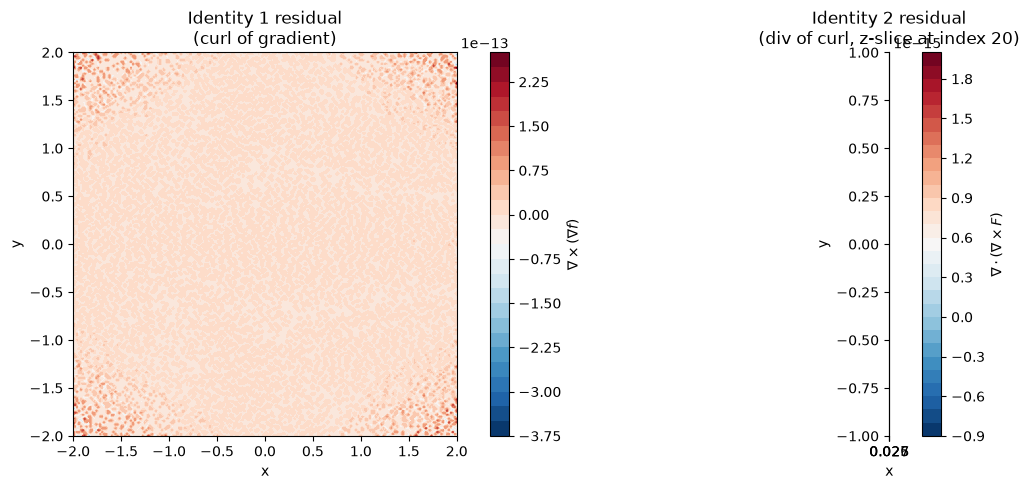

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].contourf(X, Y, curl_of_grad_num, levels=30, cmap="RdBu_r")
fig.colorbar(im0, ax=axes[0], label=r"$\nabla\times(\nabla f)$")
axes[0].set_title("Identity 1 residual\n(curl of gradient)")
axes[0].set_xlabel("x"); axes[0].set_ylabel("y")
axes[0].set_aspect("equal")

mid = n // 2
im1 = axes[1].contourf(Xg[:, :, mid], Yg[:, :, mid], div_of_curl_num[:, :, mid], levels=30, cmap="RdBu_r")
fig.colorbar(im1, ax=axes[1], label=r"$\nabla\cdot(\nabla\times F)$")
axes[1].set_title(f"Identity 2 residual\n(div of curl, z-slice at index {mid})")
axes[1].set_xlabel("x"); axes[1].set_ylabel("y")
axes[1].set_aspect("equal")

fig.tight_layout()
plt.show()


**How to read this.** Both panels are essentially flat at zero — on the
order of $10^{-13}$, i.e. floating-point noise, not $O(\Delta x^2)$
discretization error like you'd see elsewhere in this project (compare to
the $\nabla\cdot F$ colorbar in notebook 02, which spans $O(1)$).

That's more than "small" — it's a genuinely different regime, and worth
pausing on. `np.gradient` applies the *same fixed linear stencil* along
each axis regardless of what's stored in the grid. Taking a derivative
along $x$ then $y$ applies those two stencils in sequence; taking $y$ then
$x$ applies them in the other order. Because both stencils are just linear
combinations of grid values, and matrix multiplication of two fixed linear
operators along independent axes commutes, the *discrete* mixed partials
satisfy $D_x D_y = D_y D_x$ **exactly** — not approximately — for any input
array, before any question of grid resolution even comes up. The residual
you're seeing is purely floating-point round-off (accumulated over several
arithmetic operations), so refining the grid won't shrink it appreciably —
it's already at the noise floor of `float64`.

This is a stronger and slightly different guarantee than the `O(Δx²)`
truncation-error story in notebook 06: those identities are about how well
a *discrete* derivative approximates a *continuous* one; this one is about
two discrete operators commuting with each other regardless of the
function they're applied to.

## 5. Exercise

There's a third identity that's *not* generally zero — it's how the
**Laplacian** $\nabla^2 f$ is defined:

$$\nabla \cdot (\nabla f) = \nabla^2 f = \frac{\partial^2 f}{\partial x^2} + \frac{\partial^2 f}{\partial y^2}$$

Using `f = X**2 + Y**2` on a grid, compute `ops.gradient_2d` followed by
`ops.divergence_2d` and confirm the result is the constant `4` everywhere
(matches $\nabla^2(x^2+y^2) = 2 + 2 = 4$ by hand). Why does *this*
composition not vanish like the other two, even though it also involves
two derivative operators in sequence?

(Hint: look at which operator comes first in each identity, and whether the
two component derivatives being subtracted are of the *same* underlying
quantity or of *different* ones.)


In [7]:
# Your answer here.
# f = X**2 + Y**2
# df_dx, df_dy = ops.gradient_2d(f, dx, dy)
# laplacian = ops.divergence_2d(df_dx, df_dy, dx, dy)
# ...
